<a href="https://colab.research.google.com/github/Dapirz/amazon-books-sentiment-analysis/blob/main/Copy_of_Analisis_Sentimen_Amazon_Books.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Sentimen Amazon US Customer Reviews (Kategori Books)
### Tugas Besar: Artificial Intelligence & Big Data — *Google Colab GPU Mode*

**Arsitektur pipeline tetap sama dengan notebook awal:**

| Tahap | Tools | Peran |
|-------|-------|-------|
| Ingestion & Cleaning | **Apache Spark (PySpark)** `local[*]` | Membaca TSV Amazon Books berskala besar, cleaning, labeling, dan menyimpan ke Parquet |
| Modeling | **PyTorch + Hugging Face DistilBERT** | Fine-tuning `distilbert-base-uncased` untuk klasifikasi sentimen biner di **GPU (CUDA)** |
| Analisis Ekstra | **Pandas & WordCloud** | Analisis program Vine, pembelian terverifikasi, dan ekstraksi kata kunci per sentimen |
| Visualisasi | **Pandas → CSV** | Agregasi ringkas siap digunakan di Tableau atau Power BI |

> **Alur data:** `TSV` → *Spark DataFrame* → *Parquet* → *cleaning + labeling* → *stratified sample* → *Pandas* → *DistilBERT fine-tune (GPU)* → *evaluasi* → *agregasi CSV*.

> **Catatan label:** model tetap memakai klasifikasi biner seperti notebook awal. Rating 1 sampai 2 menjadi **negatif**, rating 4 sampai 5 menjadi **positif**, dan rating 3 dikeluarkan karena berada pada posisi netral.


---
# Persiapan Khusus Google Colab

Notebook ini kompatibel penuh untuk dijalankan di **Google Colab**. Colab adalah lingkungan Jupyter berbasis cloud yang sudah dilengkapi banyak library bawaan (PyTorch, Pandas, Scikit-Learn) dan akses GPU gratis.

Agar pipeline berjalan mulus tanpa error, lakukan beberapa penyesuaian kecil berikut di awal notebook.

> **Catatan:** Jika menjalankan di laptop lokal (bukan Colab), lewati seluruh bagian persiapan ini dan langsung mulai dari bagian *0. Konfigurasi & Import Library*.

### 1. Instalasi Library yang Belum Ada
Google Colab tidak memiliki PySpark dan Hugging Face `transformers` secara bawaan. Jalankan sel ini **pertama kali**.

In [ ]:
# Jalankan sel ini pertama kali di Google Colab
!pip install -q pyspark transformers wordcloud

### 2. Aktifkan Akses GPU Colab
Agar DistilBERT berlatih lebih cepat, pastikan GPU Colab aktif:

1. Klik menu **Runtime** > **Change runtime type**.
2. Pada dropdown *Hardware accelerator*, pilih **GPU** lalu klik **Save**.
3. Kode deteksi hardware pada bagian 0.1 otomatis membaca GPU yang tersedia dari Google Colab.

> Langkah ini dilakukan lewat menu, bukan kode.


### 3. Cara Mengakses Dataset Amazon Books dari Google Drive
Karena Colab berjalan di cloud, file dataset harus dimasukkan ke lingkungan Colab. Cara paling disarankan adalah menghubungkan **Google Drive**.

Jalankan sel berikut, lalu sesuaikan `RAW_PATH` ke lokasi file `amazon_reviews_us_Books_v1_02.tsv` di Google Drive.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Ubah RAW_PATH ke lokasi file TSV Amazon Books di Google Drive-mu.
# Contoh folder:
# MyDrive/Big Data/Dataset Final Project/amazon_reviews_us_Books_v1_02.tsv
RAW_PATH = "/content/drive/MyDrive/Colab Notebooks/amazon_reviews_us_Books_v1_02.tsv"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 4. Penyesuaian Memori PySpark
Google Colab versi gratis biasanya menyediakan RAM terbatas. Konfigurasi `spark.driver.memory` memakai `"6g"` agar lebih aman.

Jika runtime Colab crash, turunkan menjadi `"4g"`. Jika memakai Colab Pro dengan RAM lebih besar, nilai ini dapat dinaikkan sesuai kebutuhan.


## 0. Konfigurasi & Import Library
Mengimpor seluruh dependensi: PySpark (Big Data), PyTorch + Transformers (AI), scikit-learn, matplotlib, serta WordCloud.

In [ ]:
import os
import time
import numpy as np
import pandas as pd

# ----- PySpark (Big Data) -----
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

# ----- PyTorch & Hugging Face (Deep Learning) -----
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

# ----- Evaluasi & Visualisasi -----
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from tqdm.auto import tqdm

print("Versi PyTorch     :", torch.__version__)
print("CUDA tersedia?    :", torch.cuda.is_available())

Versi PyTorch     : 2.11.0+cu128
CUDA tersedia?    : True


### 0.1 Deteksi Hardware (CUDA / CPU)

In [ ]:
# Manajemen device PyTorch yang rigid
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    print(f"GPU aktif        : {torch.cuda.get_device_name(0)}")
    print(f"Memori GPU total : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("PERINGATAN: CUDA tidak terdeteksi. Training akan berjalan di CPU (jauh lebih lambat).")

print("Device terpilih  :", device)

GPU aktif        : Tesla T4
Memori GPU total : 15.64 GB
Device terpilih  : cuda


---
# A. PENGUMPULAN & PREPROCESSING DATA *(Bobot 20%)*
Seluruh tahap ini dikerjakan **terdistribusi oleh Spark**.

In [ ]:
spark = (
    SparkSession.builder
    .appName("AmazonBooks-Sentiment-Colab")
    .master("local[*]")
    .config("spark.driver.memory", "6g")
    .config("spark.driver.maxResultSize", "2g")
    .config("spark.sql.shuffle.partitions", "16")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)
print("Master       :", spark.sparkContext.master)


Spark version: 4.0.2
Master       : local[*]


In [ ]:
# Skema resmi Amazon Customer Reviews Dataset
schema = StructType([
    StructField("marketplace",       StringType(),  True),
    StructField("customer_id",       StringType(),  True),
    StructField("review_id",         StringType(),  True),
    StructField("product_id",        StringType(),  True),
    StructField("product_parent",    StringType(),  True),
    StructField("product_title",     StringType(),  True),
    StructField("product_category",  StringType(),  True),
    StructField("star_rating",       IntegerType(), True),
    StructField("helpful_votes",     IntegerType(), True),
    StructField("total_votes",       IntegerType(), True),
    StructField("vine",              StringType(),  True),
    StructField("verified_purchase", StringType(),  True),
    StructField("review_headline",   StringType(),  True),
    StructField("review_body",       StringType(),  True),
    StructField("review_date",       StringType(),  True),
])

# Di Colab, RAW_PATH sudah didefinisikan pada sel Google Drive.
# Jika menjalankan secara lokal, sesuaikan path berikut.
if "RAW_PATH" not in globals():
    RAW_PATH = "data/amazon_reviews_us_Books_v1_02.tsv"

df_raw = (
    spark.read
    .option("sep", "\t")
    .option("header", True)
    .option("quote", '"')
    .option("escape", '"')
    .option("multiLine", True)
    .option("mode", "PERMISSIVE")
    .schema(schema)
    .csv(RAW_PATH)
)

print("Path dataset:", RAW_PATH)
print("Jumlah kolom:", len(df_raw.columns))
df_raw.printSchema()


Path dataset: /content/drive/MyDrive/Colab Notebooks/amazon_reviews_us_Books_v1_02.tsv
Jumlah kolom: 15
root
 |-- marketplace: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- review_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_parent: string (nullable = true)
 |-- product_title: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- star_rating: integer (nullable = true)
 |-- helpful_votes: integer (nullable = true)
 |-- total_votes: integer (nullable = true)
 |-- vine: string (nullable = true)
 |-- verified_purchase: string (nullable = true)
 |-- review_headline: string (nullable = true)
 |-- review_body: string (nullable = true)
 |-- review_date: string (nullable = true)



In [ ]:
PARQUET_PATH = "amazon_books_reviews.parquet"

(df_raw.write
    .mode("overwrite")
    .parquet(PARQUET_PATH))

print(f"Dataset tersimpan sebagai Parquet di: {PARQUET_PATH}")

df = spark.read.parquet(PARQUET_PATH)
print("Total baris (sebelum cleaning):", df.count())


Dataset tersimpan sebagai Parquet di: amazon_books_reviews.parquet
Total baris (sebelum cleaning): 3105371


### A.4 Pembersihan Data, Labeling, dan Seleksi Kolom

Kolom yang digunakan disesuaikan dengan dataset Amazon Books:
- `review_body`
- `star_rating`
- `review_date`
- `vine`
- `verified_purchase`

Notebook ini tetap memakai klasifikasi biner agar model DistilBERT tidak berubah dari versi awal.


In [ ]:
df_clean = (
    df
    .select("review_id", "review_body", "star_rating", "review_date", "vine", "verified_purchase")
    .na.drop(subset=["review_body", "star_rating"])
    .filter(F.trim(F.col("review_body")) != "")
    .filter(F.col("star_rating") != 3)
    .withColumn(
        "label",
        F.when(F.col("star_rating") >= 4, 1).otherwise(0)
    )
)

df_clean.cache()
print("Total baris (sesudah cleaning):", df_clean.count())

print("\nDistribusi label (0=Negatif, 1=Positif):")
df_clean.groupBy("label").count().orderBy("label").show()


Total baris (sesudah cleaning): 2855454

Distribusi label (0=Negatif, 1=Positif):
+-----+-------+
|label|  count|
+-----+-------+
|    0| 404588|
|    1|2450866|
+-----+-------+



---
# B. AI MODELING DENGAN DistilBERT *(Lebih Cepat & Efisien)*

In [ ]:
# Dataset Books lebih besar, jadi sample dibuat lebih kecil agar aman di Colab.
# Model dan pipeline tetap DistilBERT + CUDA seperti notebook awal.
# Jika Colab masih kuat, fraction bisa dinaikkan ke 0.02 atau 0.05.
fractions = {0: 0.05, 1: 0.05}
df_sample = df_clean.sampleBy("label", fractions=fractions, seed=42)

print("Ukuran sample (stratified):", df_sample.count())

# Tarik ke driver sebagai Pandas DataFrame
pdf = df_sample.select("review_body", "label", "review_date", "vine", "verified_purchase").toPandas()
print("Shape Pandas DataFrame:", pdf.shape)

BALANCE = True
if BALANCE:
    n_min = pdf["label"].value_counts().min()
    pdf = (pdf.groupby("label", group_keys=False)
              .sample(n=n_min, random_state=42)
              .reset_index(drop=True))
    print("Setelah balancing:")
    print(pdf["label"].value_counts())

print("Total data untuk modeling:", len(pdf))


Ukuran sample (stratified): 142545
Shape Pandas DataFrame: (142545, 5)
Setelah balancing:
label
0    20323
1    20323
Name: count, dtype: int64
Total data untuk modeling: 40646


In [ ]:
train_df, val_df = train_test_split(
    pdf, test_size=0.2, random_state=42, stratify=pdf["label"]
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"Train: {len(train_df)} baris | Validation: {len(val_df)} baris")

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN    = 128

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print("Tokenizer dimuat:", tokenizer.__class__.__name__)

Train: 32516 baris | Validation: 8130 baris
Tokenizer dimuat: DistilBertTokenizer


In [ ]:
class AmazonReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_tensors="pt",
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }

train_dataset = AmazonReviewDataset(train_df["review_body"], train_df["label"], tokenizer, MAX_LEN)
val_dataset   = AmazonReviewDataset(val_df["review_body"],   val_df["label"],   tokenizer, MAX_LEN)

BATCH_SIZE = 32  # DistilBERT bisa handle batch lebih besar
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
print("DataLoader siap. Jumlah batch train:", len(train_loader))

DataLoader siap. Jumlah batch train: 1017


In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)

optimizer = AdamW(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

print("Model siap di device:", next(model.parameters()).device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model siap di device: cuda:0


In [ ]:
EPOCHS = 2
total_start = time.time()

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    epoch_start = time.time()

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Training]", leave=True)

    for step, batch in enumerate(loop):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits
        loss    = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}", avg=f"{total_loss/(step+1):.4f}")

    avg_loss   = total_loss / len(train_loader)
    epoch_time = time.time() - epoch_start
    print(f"[Epoch {epoch+1}/{EPOCHS}] avg_loss={avg_loss:.4f} | waktu epoch: {epoch_time:.1f}s")

print(f"\nTraining selesai. Total waktu: {time.time() - total_start:.1f}s")

Epoch 1/2 [Training]:   0%|          | 0/1017 [00:00<?, ?it/s]

[Epoch 1/2] avg_loss=0.2778 | waktu epoch: 362.3s


Epoch 2/2 [Training]:   0%|          | 0/1017 [00:00<?, ?it/s]

[Epoch 2/2] avg_loss=0.1525 | waktu epoch: 360.0s

Training selesai. Total waktu: 722.4s


Accuracy : 0.9004
F1-Score : 0.9045



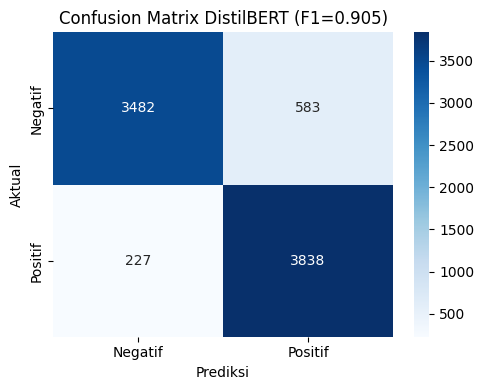

In [ ]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        preds  = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds)
print(f"Accuracy : {acc:.4f}")
print(f"F1-Score : {f1:.4f}\n")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negatif", "Positif"],
            yticklabels=["Negatif", "Positif"])
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title(f"Confusion Matrix DistilBERT (F1={f1:.3f})")
plt.tight_layout()
plt.savefig("confusion_matrix_distilbert.png", dpi=150)
plt.show()

---
# C. ANALISIS DETAIL, WORD CLOUD & VISUALISASI DATA

In [ ]:
val_df = val_df.copy()
val_df["prediction"] = all_preds
val_df["sentiment"]  = val_df["prediction"].map({0: "Negatif", 1: "Positif"})
val_df.head()

,review_body,label,review_date,vine,verified_purchase,prediction,sentiment
0,This is a third book by Jane Green for me and ...,1,2000-09-21,N,N,1,Positif
1,This &quot;teacher's guide&quot; is by it's ow...,0,2002-03-17,N,Y,0,Negatif
2,This tale of a sexy lesbian witch seducing a l...,1,1999-10-31,N,N,1,Positif
3,The book claims to be a scholarly study of the...,0,2000-09-09,N,N,0,Negatif
4,"Many dog lovers, like me, bought this book hop...",0,2004-12-12,N,N,0,Negatif


### C.1 Analisis Komparatif: Ulasan Vine vs Organik
Untuk melihat apakah status pengulas program Vine `Y` memiliki kecenderungan memberikan review positif lebih sering dibanding ulasan organik.


--- ANALISIS VINE PROGRAM ---

Persentase Sentimen Berdasarkan Akun Vine:
sentiment      Negatif    Positif
vine_binary                      
0            45.621156  54.378844


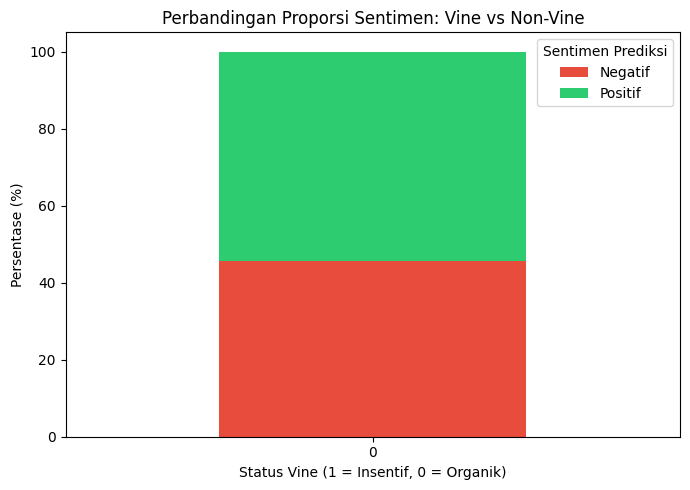

In [ ]:
print("--- ANALISIS VINE PROGRAM ---")
val_df["vine_binary"] = val_df["vine"].map({"Y": 1, "N": 0})

vine_analysis = pd.crosstab(val_df["vine_binary"], val_df["sentiment"], normalize="index") * 100
print("\nPersentase Sentimen Berdasarkan Akun Vine:")
print(vine_analysis)

plt.figure(figsize=(7, 5))
vine_analysis.plot(kind="bar", stacked=True, color=["#e74c3c", "#2ecc71"], ax=plt.gca())
plt.title("Perbandingan Proporsi Sentimen: Vine vs Non-Vine")
plt.xlabel("Status Vine (1 = Insentif, 0 = Organik)")
plt.ylabel("Persentase (%)")
plt.xticks(rotation=0)
plt.legend(title="Sentimen Prediksi")
plt.tight_layout()
plt.savefig("vine_vs_non_vine_sentiment.png", dpi=150)
plt.show()


### C.2 Analisis Komparatif: Verified Purchase vs Non-Verified
Analisis ini digunakan untuk melihat pola sentimen antara pembeli terverifikasi dan ulasan yang tidak terverifikasi.


--- ANALISIS VERIFIED PURCHASE ---

Persentase Sentimen Berdasarkan Verified Purchase:
sentiment          Negatif    Positif
verified_binary                      
0                45.431707  54.568293
1                48.148148  51.851852


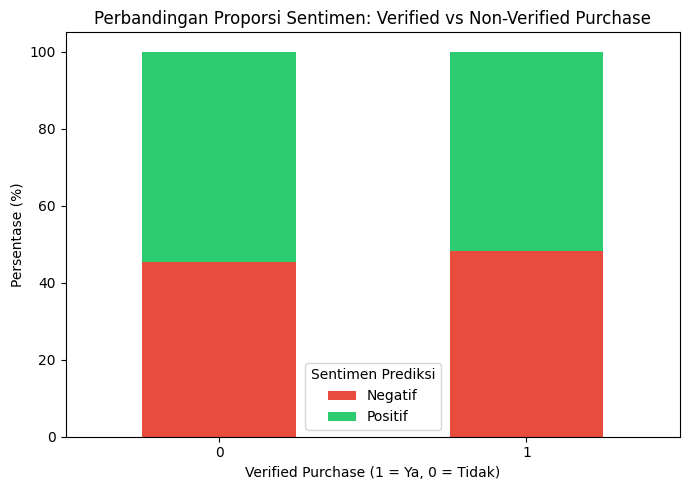

In [ ]:
print("--- ANALISIS VERIFIED PURCHASE ---")
val_df["verified_binary"] = val_df["verified_purchase"].map({"Y": 1, "N": 0})

verified_analysis = pd.crosstab(val_df["verified_binary"], val_df["sentiment"], normalize="index") * 100
print("\nPersentase Sentimen Berdasarkan Verified Purchase:")
print(verified_analysis)

plt.figure(figsize=(7, 5))
verified_analysis.plot(kind="bar", stacked=True, color=["#e74c3c", "#2ecc71"], ax=plt.gca())
plt.title("Perbandingan Proporsi Sentimen: Verified vs Non-Verified Purchase")
plt.xlabel("Verified Purchase (1 = Ya, 0 = Tidak)")
plt.ylabel("Persentase (%)")
plt.xticks(rotation=0)
plt.legend(title="Sentimen Prediksi")
plt.tight_layout()
plt.savefig("verified_purchase_sentiment.png", dpi=150)
plt.show()


### C.3 Generasi Word Cloud per Sentimen

--- GENERASI WORD CLOUD ---


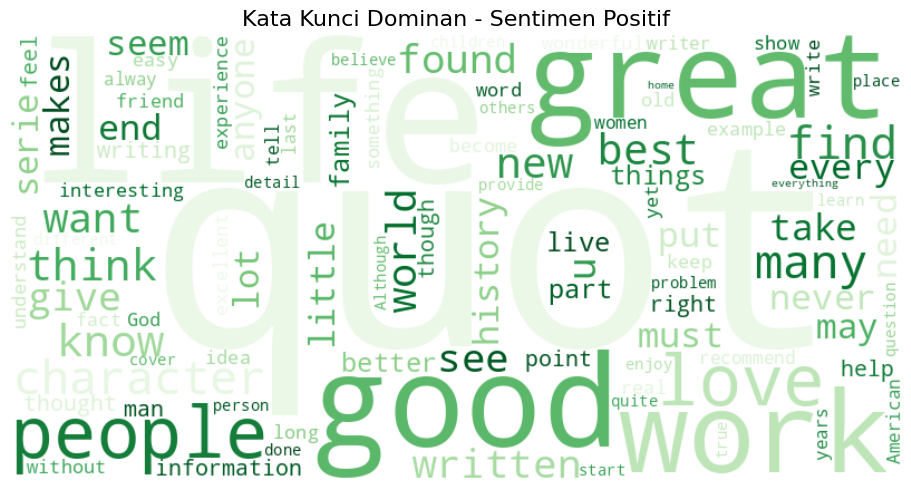

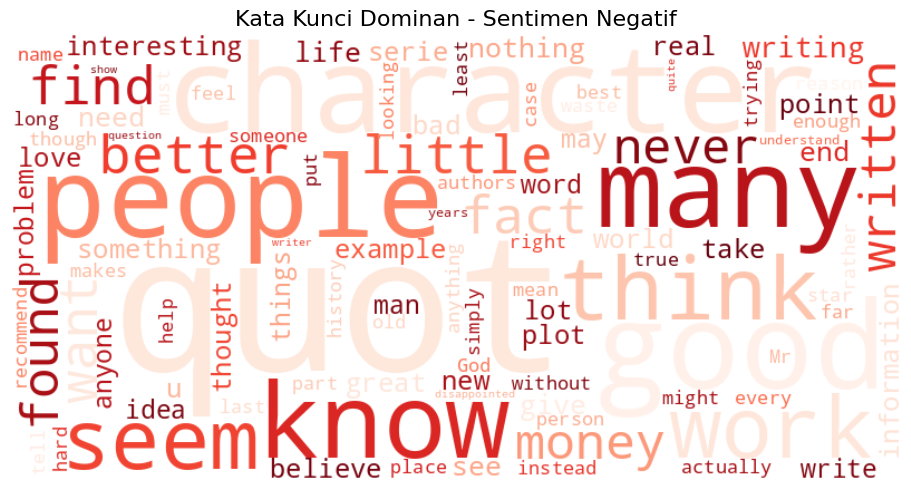

In [ ]:
print("--- GENERASI WORD CLOUD ---")

import re

def clean_html(text):
    """Hapus semua tag HTML dari teks review."""
    return re.sub(r'<[^>]+>', ' ', str(text))

# Stopword dasar WordCloud
custom_stopwords = set(STOPWORDS)

# Stopword domain Books (terlalu umum dan kurang informatif untuk sentimen)
custom_stopwords.update([
    # Kata produk yang sudah diwakili oleh konteks dataset
    "book", "books", "kindle", "amazon", "product", "edition",
    "author", "novel", "story", "stories", "chapter", "chapters",
    "page", "pages", "reader", "read", "reading",
    # Kata aksi netral
    "buy", "bought", "will", "use", "using", "used",
    "get", "got", "go", "going", "make", "made", "come",
    "say", "said", "look", "looks",
    # Kata filler tanpa nilai sentimen yang kuat
    "even", "really", "one", "two", "another", "much",
    "still", "now", "well", "first", "back", "way", "thing",
    # Artefak HTML
    "br",
    # Kata konteks waktu atau transaksi
    "purchased", "purchase", "item", "review", "month", "year",
    "day", "week", "time",
])

def generate_sentiment_wordcloud(data, sentiment_label, color_palette, filename):
    cleaned_reviews = data[data["sentiment"] == sentiment_label]["review_body"].astype(str).apply(clean_html)
    text_space = " ".join(cleaned_reviews)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        stopwords=custom_stopwords,
        colormap=color_palette,
        max_words=100,
        random_state=42
    ).generate(text_space)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(f"Kata Kunci Dominan - Sentimen {sentiment_label}", fontsize=16)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

generate_sentiment_wordcloud(val_df, "Positif", "Greens", "wordcloud_positif.png")
generate_sentiment_wordcloud(val_df, "Negatif", "Reds",   "wordcloud_negatif.png")


### C.4 Analisis Tren Sentimen & Pola Musiman

In [ ]:
val_df["review_date"] = pd.to_datetime(val_df["review_date"], errors="coerce")
val_df_time = val_df.dropna(subset=["review_date"]).copy()
val_df_time["year"]       = val_df_time["review_date"].dt.year
val_df_time["month"]      = val_df_time["review_date"].dt.month
val_df_time["month_name"] = val_df_time["review_date"].dt.strftime("%b")
val_df_time["year_month"] = val_df_time["review_date"].dt.to_period("M").astype(str)
month_labels = ["Jan","Feb","Mar","Apr","Mei","Jun","Jul","Agt","Sep","Okt","Nov","Des"]

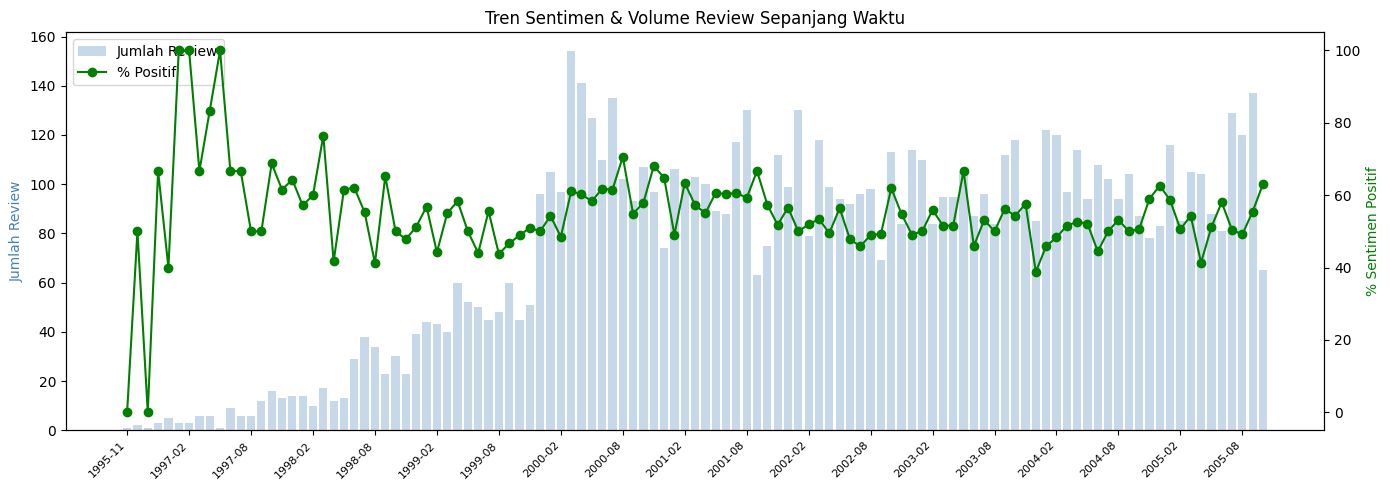

In [ ]:
# ── (1) Tren Bulanan Sepanjang Waktu ──────────────────────────────────────────
trend = (
    val_df_time.groupby("year_month")["prediction"]
    .agg(positive_ratio="mean", total_reviews="count")
    .reset_index()
    .sort_values("year_month")
)
trend["positive_ratio"] = (100 * trend["positive_ratio"]).round(2)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.bar(trend["year_month"], trend["total_reviews"], color="steelblue", alpha=0.3, label="Jumlah Review")
ax2.plot(trend["year_month"], trend["positive_ratio"], color="green", marker="o", linewidth=1.5, label="% Positif")

ticks = trend["year_month"].values
ax1.set_xticks(ticks[::6])
ax1.set_xticklabels(ticks[::6], rotation=45, ha="right", fontsize=8)
ax1.set_ylabel("Jumlah Review", color="steelblue")
ax2.set_ylabel("% Sentimen Positif", color="green")
ax1.set_title("Tren Sentimen & Volume Review Sepanjang Waktu")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.savefig("sentiment_trend_full.png", dpi=150)
plt.show()

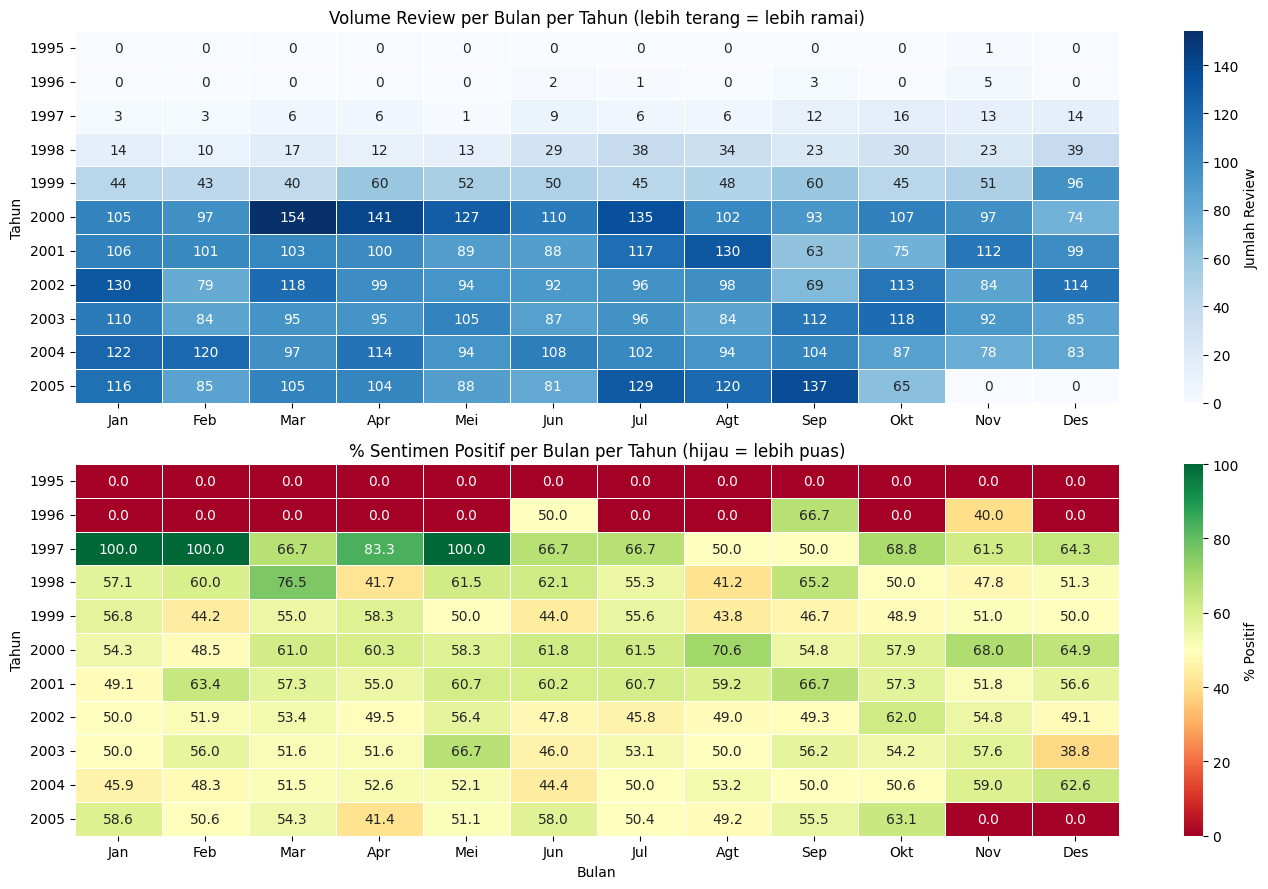

In [ ]:
# ── (2) Pola Musiman: Volume Review per Bulan (lintas tahun) ──────────────────
monthly_volume = (
    val_df_time.groupby(["year", "month"])["prediction"]
    .agg(total_reviews="count", positive_ratio="mean")
    .reset_index()
)
monthly_volume["positive_ratio"] = (100 * monthly_volume["positive_ratio"]).round(2)

pivot_vol  = monthly_volume.pivot(index="year", columns="month", values="total_reviews").fillna(0)
pivot_sent = monthly_volume.pivot(index="year", columns="month", values="positive_ratio").fillna(0)
pivot_vol.columns  = [month_labels[c-1] for c in pivot_vol.columns]
pivot_sent.columns = [month_labels[c-1] for c in pivot_sent.columns]

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
import seaborn as sns

sns.heatmap(pivot_vol.astype(int), ax=axes[0], cmap="Blues", annot=True, fmt="d",
            linewidths=0.5, cbar_kws={"label": "Jumlah Review"})
axes[0].set_title("Volume Review per Bulan per Tahun (lebih terang = lebih ramai)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Tahun")

sns.heatmap(pivot_sent, ax=axes[1], cmap="RdYlGn", annot=True, fmt=".1f",
            linewidths=0.5, vmin=0, vmax=100, cbar_kws={"label": "% Positif"})
axes[1].set_title("% Sentimen Positif per Bulan per Tahun (hijau = lebih puas)")
axes[1].set_xlabel("Bulan")
axes[1].set_ylabel("Tahun")

plt.tight_layout()
plt.savefig("seasonal_heatmap.png", dpi=150)
plt.show()

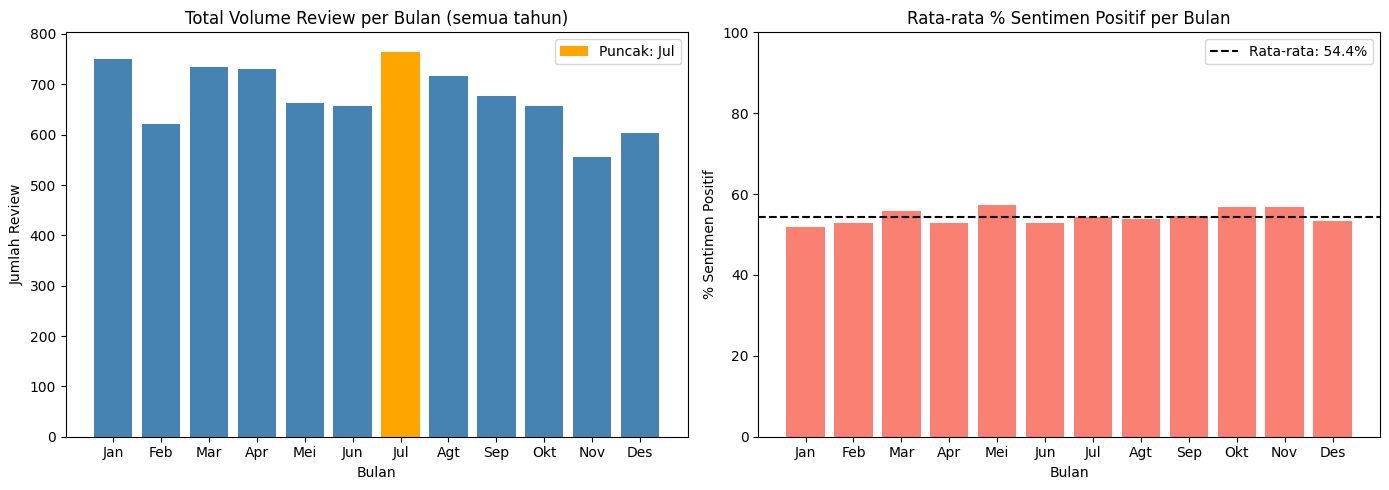


===== INSIGHT MUSIMAN =====
Bulan paling ramai beli  : Jul (765 review)
Bulan paling sepi beli   : Nov (556 review)
Bulan paling puas        : Mei (57.3% positif)
Bulan paling tidak puas  : Jan (51.9% positif)


In [ ]:
# ── (3) Rata-rata Musiman: Bulan Mana Paling Ramai & Paling Puas? ─────────────
seasonal = (
    val_df_time.groupby("month")["prediction"]
    .agg(avg_reviews="count", avg_positive="mean")
    .reset_index()
)
seasonal["avg_positive"] = (100 * seasonal["avg_positive"]).round(2)
seasonal["month_name"] = [month_labels[m-1] for m in seasonal["month"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(seasonal["month_name"], seasonal["avg_reviews"], color="steelblue")
axes[0].set_title("Total Volume Review per Bulan (semua tahun)")
axes[0].set_xlabel("Bulan")
axes[0].set_ylabel("Jumlah Review")
peak_month = seasonal.loc[seasonal["avg_reviews"].idxmax(), "month_name"]
axes[0].bar(seasonal[seasonal["month_name"]==peak_month]["month_name"],
            seasonal[seasonal["month_name"]==peak_month]["avg_reviews"],
            color="orange", label=f"Puncak: {peak_month}")
axes[0].legend()

colors = ["green" if v >= 70 else "salmon" for v in seasonal["avg_positive"]]
axes[1].bar(seasonal["month_name"], seasonal["avg_positive"], color=colors)
axes[1].axhline(y=seasonal["avg_positive"].mean(), color="black", linestyle="--",
                label=f'Rata-rata: {seasonal["avg_positive"].mean():.1f}%')
axes[1].set_title("Rata-rata % Sentimen Positif per Bulan")
axes[1].set_xlabel("Bulan")
axes[1].set_ylabel("% Sentimen Positif")
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.savefig("seasonal_bar.png", dpi=150)
plt.show()

# ── (4) Ringkasan Insight ──────────────────────────────────────────────────────
peak_vol   = seasonal.loc[seasonal["avg_reviews"].idxmax()]
low_vol    = seasonal.loc[seasonal["avg_reviews"].idxmin()]
peak_sat   = seasonal.loc[seasonal["avg_positive"].idxmax()]
low_sat    = seasonal.loc[seasonal["avg_positive"].idxmin()]

print("\n===== INSIGHT MUSIMAN =====")
print(f"Bulan paling ramai beli  : {peak_vol['month_name']} ({int(peak_vol['avg_reviews'])} review)")
print(f"Bulan paling sepi beli   : {low_vol['month_name']} ({int(low_vol['avg_reviews'])} review)")
print(f"Bulan paling puas        : {peak_sat['month_name']} ({peak_sat['avg_positive']:.1f}% positif)")
print(f"Bulan paling tidak puas  : {low_sat['month_name']} ({low_sat['avg_positive']:.1f}% positif)")
print("===========================")

### C.5 Ekspor CSV untuk Dashboard

In [ ]:
sentiment_ratio = val_df["sentiment"].value_counts().rename_axis("sentiment").reset_index(name="jumlah")
sentiment_ratio["persentase"] = (100 * sentiment_ratio["jumlah"] / sentiment_ratio["jumlah"].sum()).round(2)

sentiment_ratio.to_csv("dashboard_sentiment_ratio.csv", index=False)
trend.to_csv("dashboard_sentiment_trend.csv", index=False)
vine_analysis.to_csv("dashboard_vine_analysis.csv")
verified_analysis.to_csv("dashboard_verified_purchase_analysis.csv")

print("File CSV siap-dashboard telah diekspor.")

# Tutup SparkSession dengan penanganan error jika koneksi sudah terputus
try:
    spark.stop()
    print("SparkSession ditutup.")
except Exception as e:
    print(f"SparkSession sudah tertutup atau tidak terjangkau: {e}")

print("Pipeline selesai.")


File CSV siap-dashboard telah diekspor.
SparkSession ditutup.
Pipeline selesai.
